# Behavior Data Overview

This notebook displays behavior overview tables and figures generated into the configured local data analysis-output folder.

In [13]:
import pandas as pd
from IPython.display import Image, display

from dal_monte_2022_analysis.behav.analysis.behavior_overview import behavior_overview_output_dir, build_behavior_overview

OUT = behavior_overview_output_dir('configs/project.yaml')
OUT

PosixPath('/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/behavior_overview')

## Regenerate Outputs

In [14]:
# Optional: rerun the full build. This streams all sessions and may take a few minutes.
# OUT = build_behavior_overview('configs/project.yaml')

## Recording And Period Counts

In [15]:
display(pd.read_csv(OUT / 'session_summary.csv'))
display(pd.read_csv(OUT / 'period_count_summary_by_state.csv'))
display(pd.read_csv(OUT / 'period_duration_summary_by_state.csv'))

,n_days,n_5min_sessions,mean_session_duration_min,median_session_duration_min,sd_session_duration_min
0,42,417,4.974793,4.975017,0.003357


,state,n_periods
0,interactive,2728
1,non_interactive,2771


,state,n,mean_s,median_s,sd_s,min_s,q25_s,q75_s,max_s
0,interactive,2728,26.931391,21.1945,18.958324,0.051,14.3230,34.92225,147.708
1,non_interactive,2771,18.405082,11.7880,20.808824,0.009,5.4955,23.45300,214.541


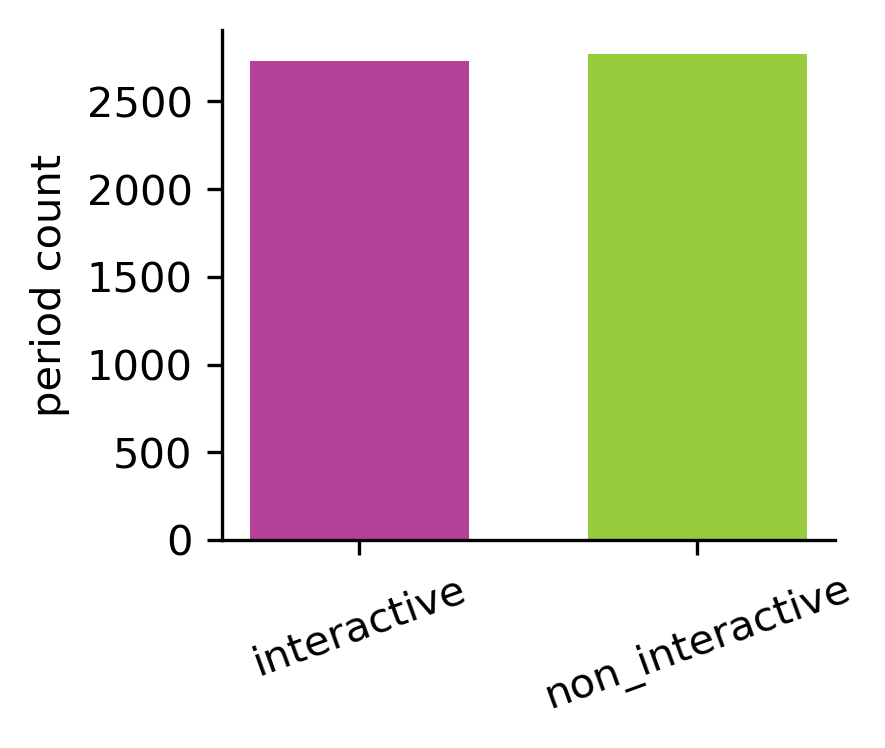

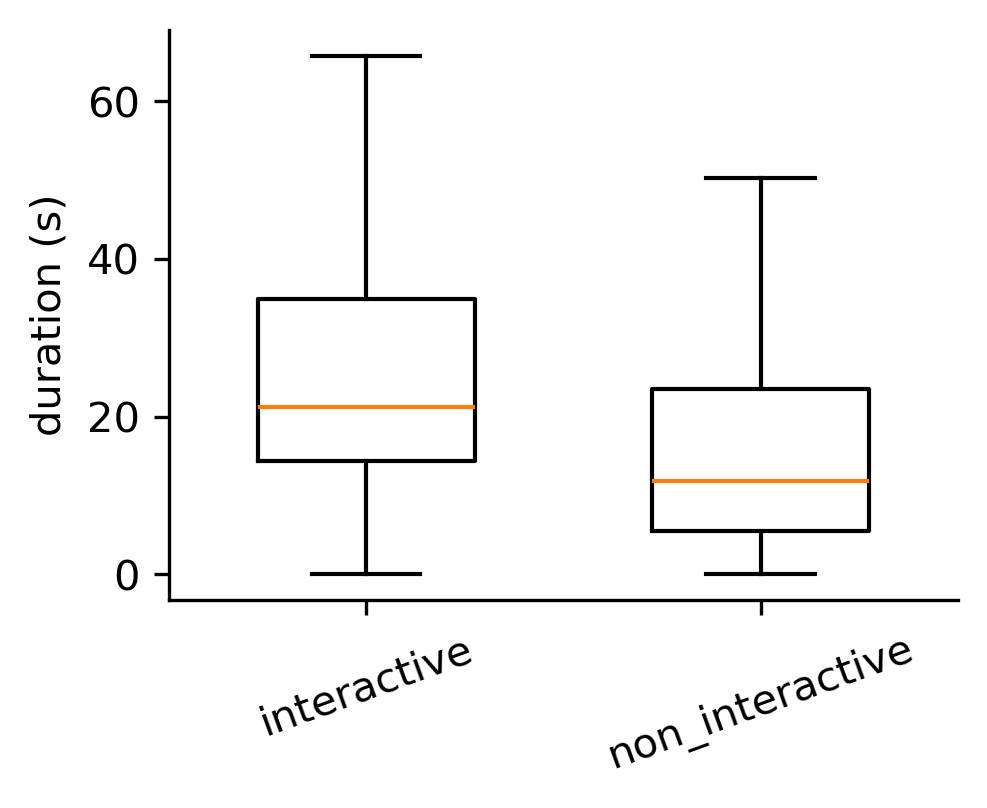

In [16]:
display(Image(filename=str(OUT / 'period_counts.png')))
display(Image(filename=str(OUT / 'period_duration_boxplot.png')))

## Fixation Probabilities

,phase,agent,roi,probability_type,n_sessions,mean_probability,median_probability,sd_probability,total_fixation_samples,total_samples,pooled_probability
0,interactive,m1,face,M1 face,417,0.113419,0.101489,0.059515,8823411,73468835,0.120097
1,interactive,m1,object,M1 object,417,0.029033,0.022039,0.023228,2013442,73468835,0.027405
2,interactive,m2,face,M2 face,417,0.093868,0.075285,0.056548,6975169,73468835,0.094941
3,non_interactive,m1,face,M1 face,417,0.034916,0.018967,0.043527,1494650,51000483,0.029307
4,non_interactive,m1,object,M1 object,417,0.038711,0.028504,0.033350,2192149,51000483,0.042983
5,non_interactive,m2,face,M2 face,417,0.029015,0.018202,0.032965,1505585,51000483,0.029521
6,whole,m1,face,M1 face,417,0.082911,0.068410,0.054278,10318061,124469318,0.082896
7,whole,m1,object,M1 object,417,0.033786,0.025730,0.025390,4205591,124469318,0.033788
8,whole,m2,face,M2 face,417,0.068134,0.055283,0.043110,8480754,124469318,0.068135


,probability_type,n_sessions,interactive_mean,non_interactive_mean,mean_difference,median_difference,wilcoxon_statistic,wilcoxon_p,paired_t_statistic,paired_t_p
0,M1 face,417,0.113419,0.034916,0.078503,0.071737,404.0,8.269945e-69,34.870222,1.531223e-125
1,M2 face,417,0.093868,0.029015,0.064853,0.056736,712.0,7.403776e-68,28.686135,1.261067e-100
2,M1 object,417,0.029033,0.038711,-0.009679,-0.004930,28518.0,9.662974e-10,-6.829547,3.032818e-11


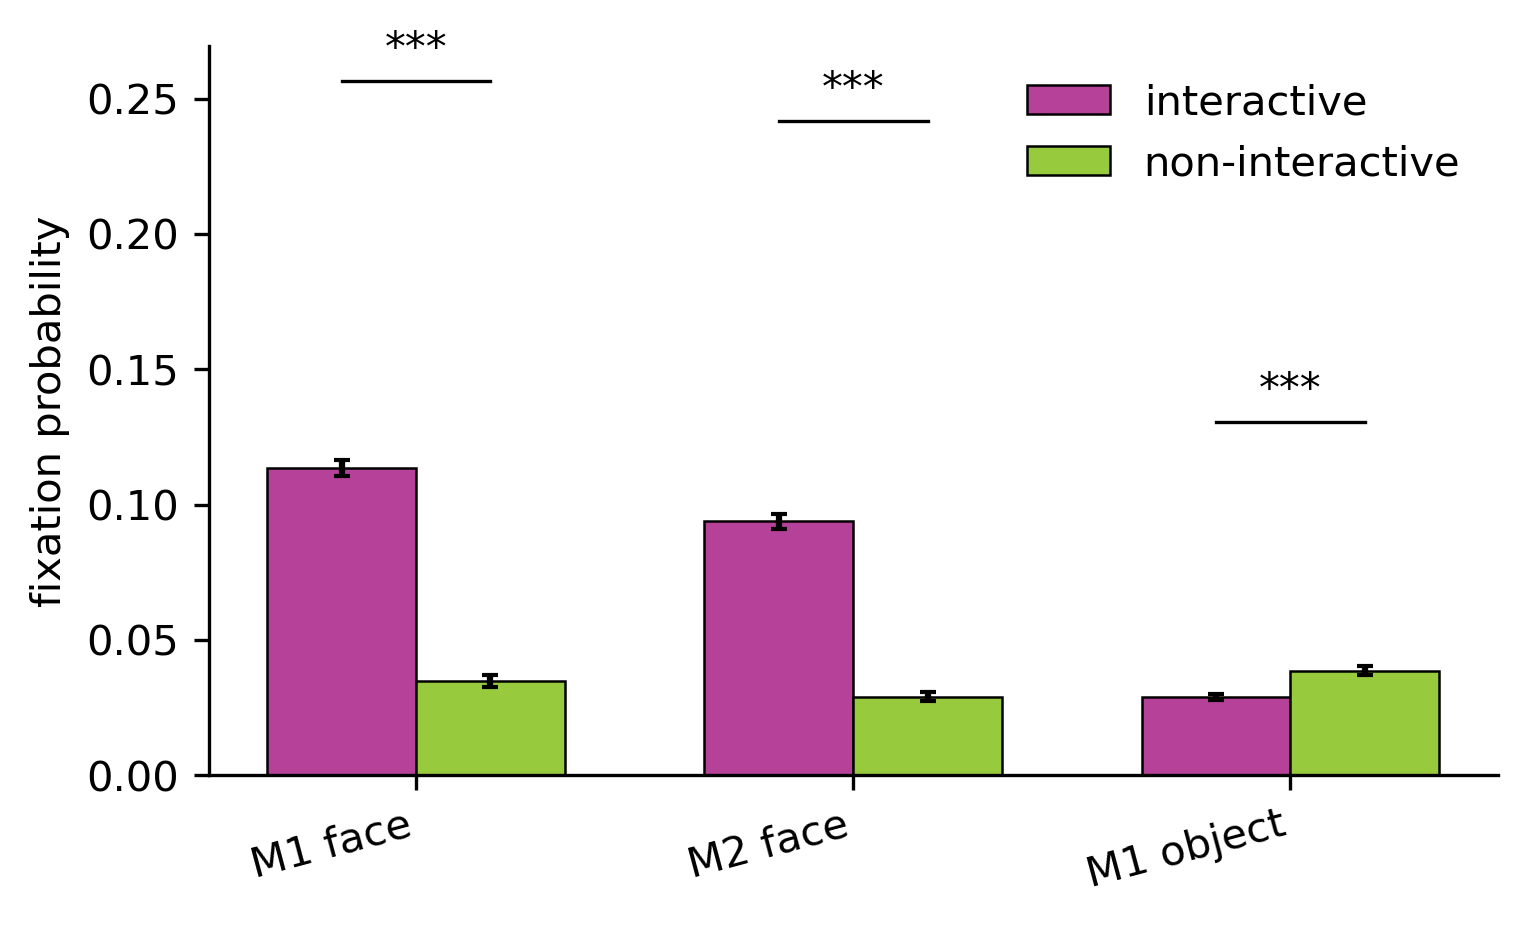

In [17]:
display(pd.read_csv(OUT / 'fixation_probability_summary.csv'))
display(pd.read_csv(OUT / 'fixation_probability_interactive_vs_non_interactive_stats.csv'))
display(Image(filename=str(OUT / 'fixation_probability_interactive_vs_non_interactive.png')))

## Remapped Fixation Heatmaps

M1 gaze is affinely remapped from the face, left-object, and right-object ROI centers to a canonical triangle. M2 gaze is centered and scaled by the face ROI bounding box. Heatmaps are fixation samples only, aggregated across all sessions, and compared between interactive states.

,agent,phase,total_fixation_heat,face_heat_fraction
0,m1,interactive,44959686.0,0.140022
1,m1,non_interactive,27562774.0,0.039149
2,m1,interactive_minus_non_interactive,17396912.0,0.100872
3,m2,interactive,28183382.0,0.196233
4,m2,non_interactive,14071321.0,0.084999
5,m2,interactive_minus_non_interactive,14112061.0,0.111234


M1 fixation heatmap comparison


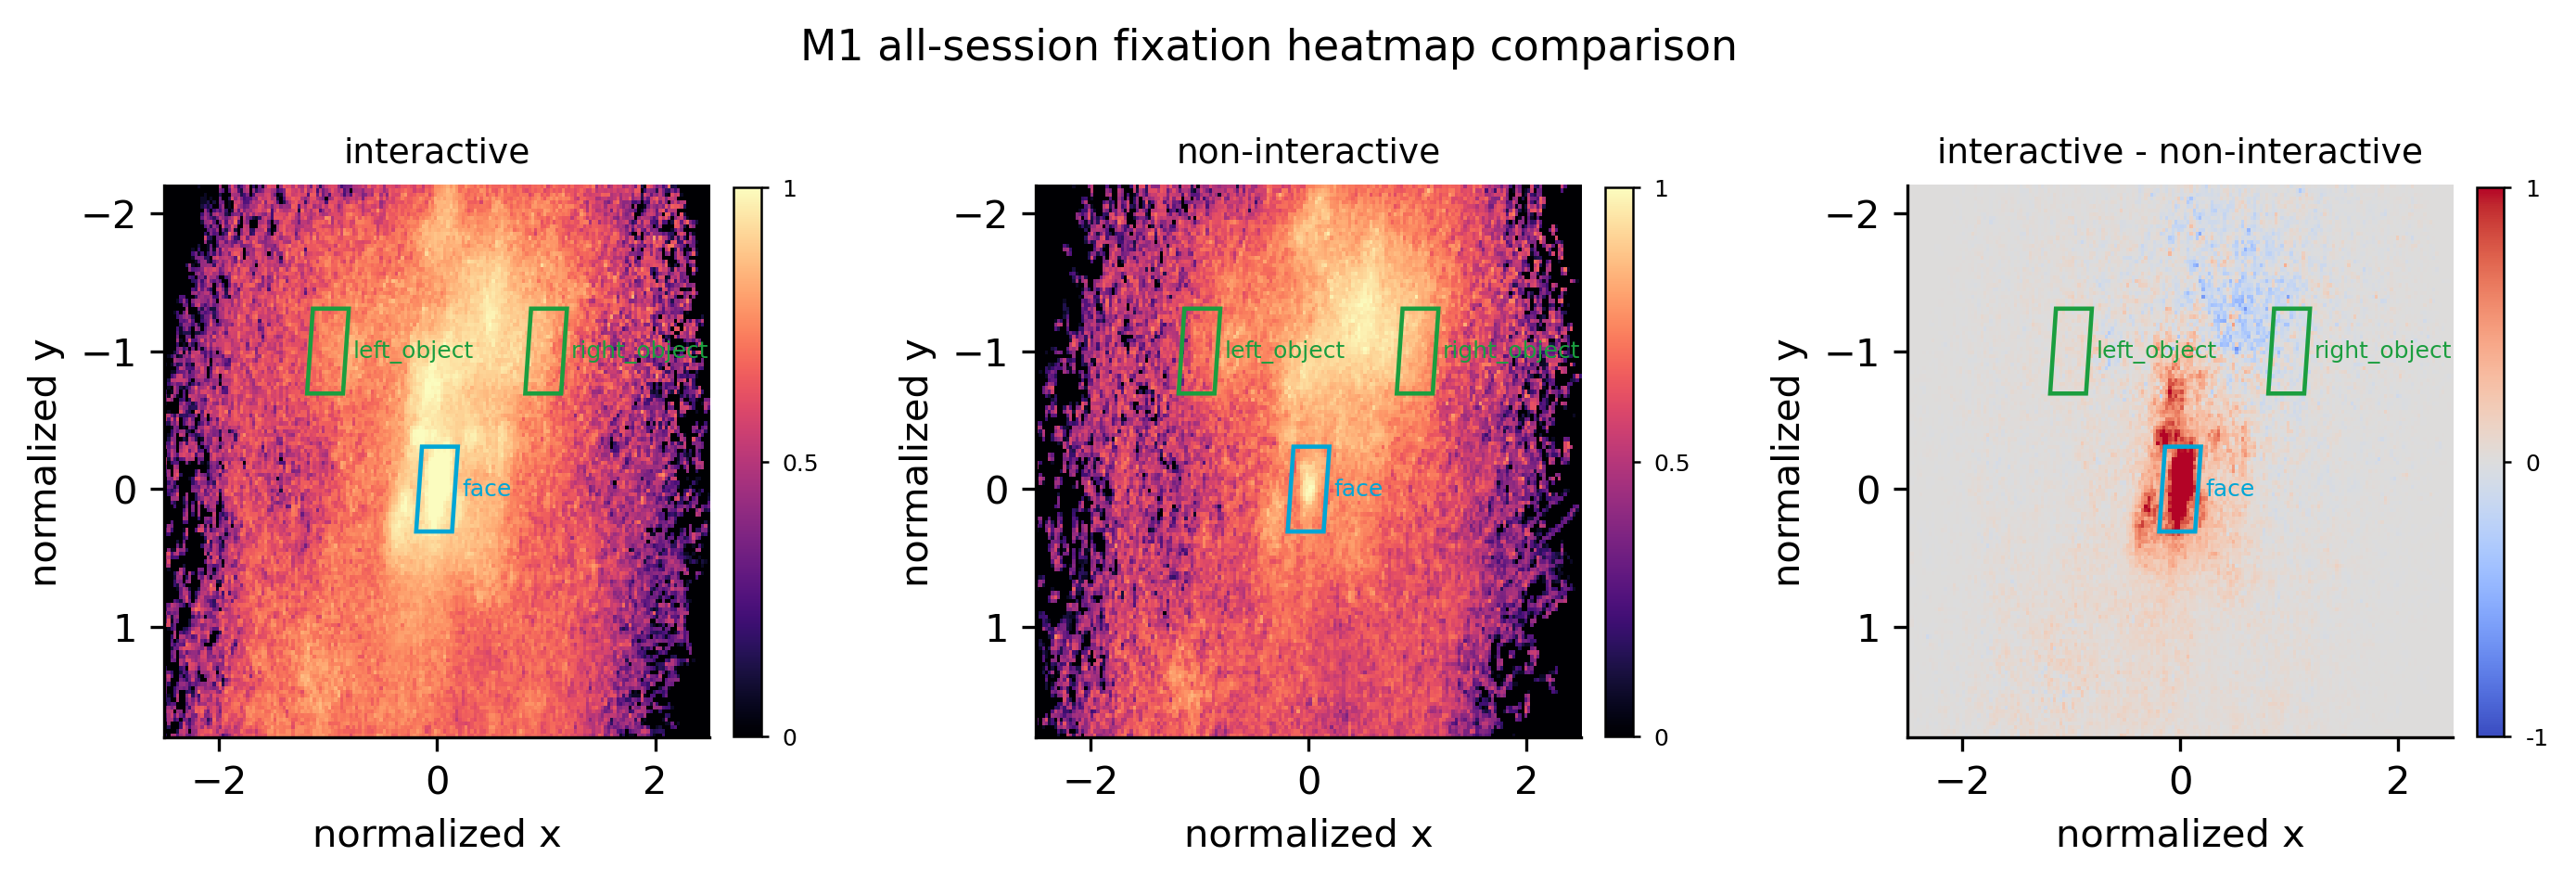

M2 fixation heatmap comparison


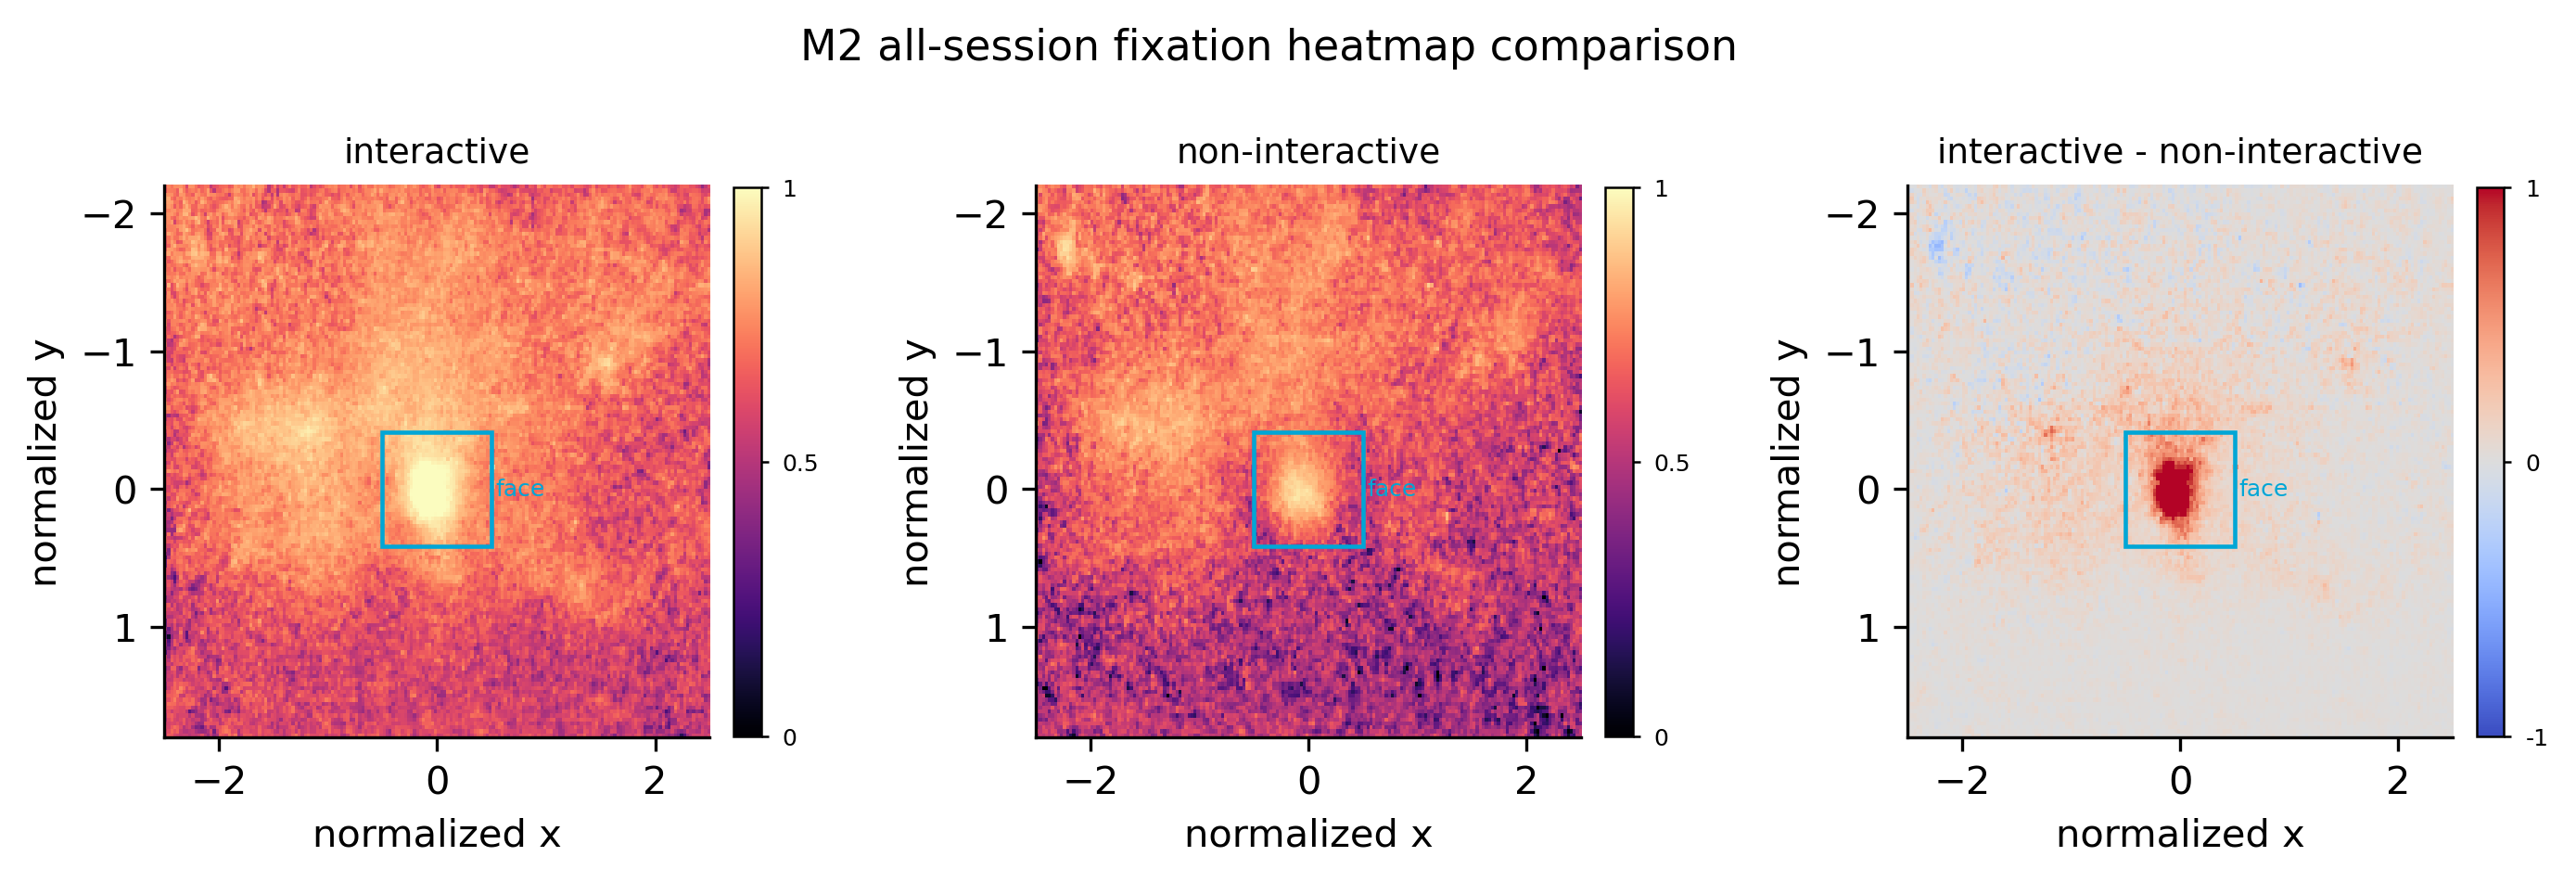

In [18]:
display(pd.read_csv(OUT / 'heatmap_face_density_summary.csv'))
for agent in ('m1', 'm2'):
    print(f'{agent.upper()} fixation heatmap comparison')
    display(Image(filename=str(OUT / f'heatmap_{agent}_fixations_interactive_vs_non_interactive.png')))